# Exercício — Previsão de inadimplência (Aula IAML 05)
Notebook com as 6 partes do exercício e os desafios extras. Pré-requisito: ter rodado `python gerar_dados.py` na pasta do projeto (este notebook fica na mesma pasta que `config.py` e `treinar.py`).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
from config import PROBLEMAS, DADOS, SEMENTE
from treinar import candidatos, criar_pipeline, dividir
sns.set_theme(style="whitegrid"); pd.set_option("display.precision", 4)
df = pd.read_csv(DADOS / "credito.csv")
df.head()

,id_contrato,idade,renda_mensal,tempo_emprego_anos,score_credito,dividas_ativas,possui_imovel,finalidade,prazo_meses,valor_emprestimo,inadimplente
0,E00001,39.0,2060.0,6.3,533.0,0,sim,veiculo,36,4400.0,0
1,E00002,33.0,4910.0,4.5,584.0,0,nao,educacao,24,24600.0,0
2,E00003,45.0,1690.0,7.4,662.0,0,nao,veiculo,60,7300.0,0
3,E00004,48.0,7560.0,18.5,622.0,2,sim,educacao,48,4300.0,0
4,E00005,55.0,1800.0,0.4,797.0,2,sim,pessoal,12,1000.0,0


## Parte 1 — Análise exploratória

In [2]:
print(df.shape)
print(df["inadimplente"].value_counts())
print("Proporção de inadimplentes:", round(df["inadimplente"].mean(), 4))
print("\nAusentes por coluna:"); print(df.isna().sum()[df.isna().sum() > 0])

(6000, 11)
inadimplente
0    4738
1    1262
Name: count, dtype: int64
Proporção de inadimplentes: 0.2103

Ausentes por coluna:
renda_mensal          231
tempo_emprego_anos    183
dtype: int64


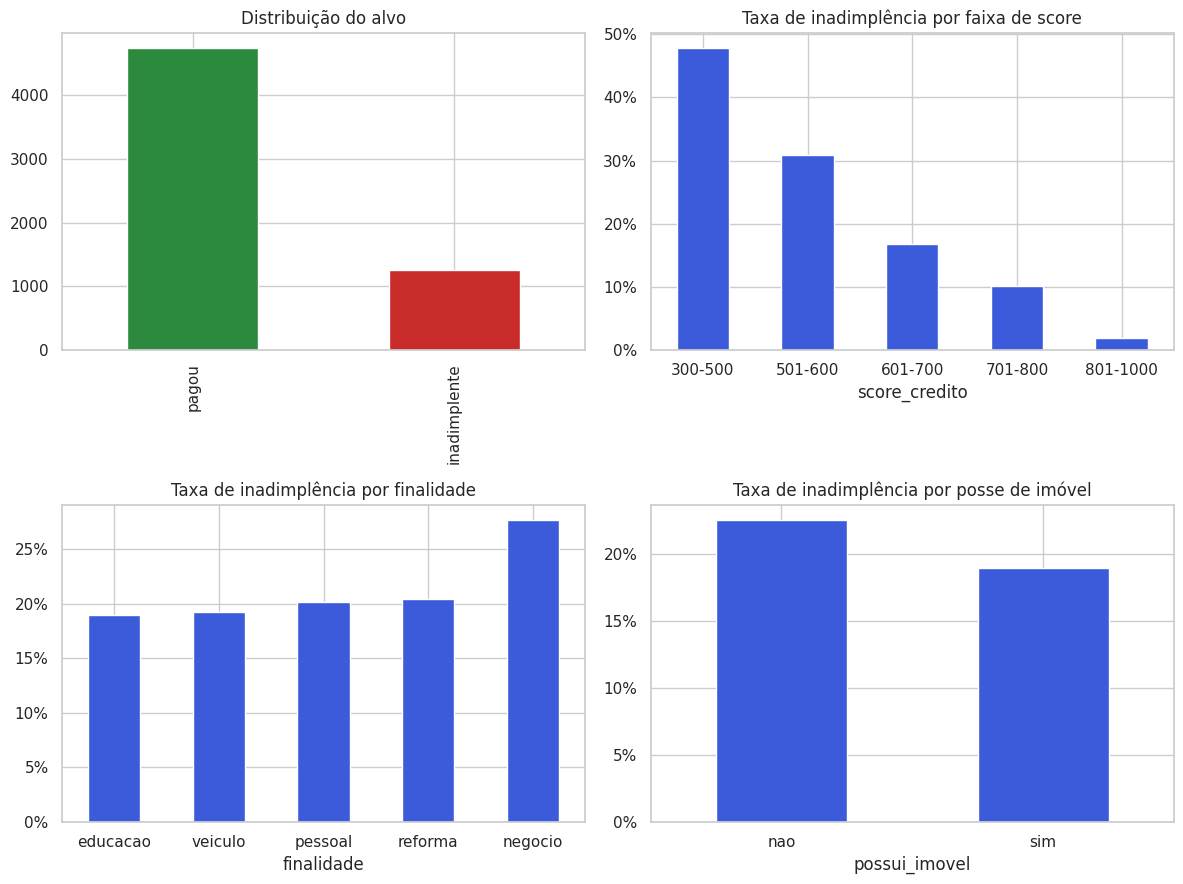

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
df["inadimplente"].map({0: "pagou", 1: "inadimplente"}).value_counts().plot.bar(ax=ax[0,0], color=["#2b8a3e", "#c92a2a"])
ax[0,0].set_title("Distribuição do alvo"); ax[0,0].set_xlabel("")
faixas = pd.cut(df.score_credito, [299, 500, 600, 700, 800, 1000], labels=["300-500","501-600","601-700","701-800","801-1000"])
df.groupby(faixas, observed=True).inadimplente.mean().plot.bar(ax=ax[0,1], color="#3b5bdb")
ax[0,1].set_title("Taxa de inadimplência por faixa de score"); ax[0,1].set_xlabel("score_credito")
df.groupby("finalidade").inadimplente.mean().sort_values().plot.bar(ax=ax[1,0], color="#3b5bdb")
ax[1,0].set_title("Taxa de inadimplência por finalidade")
df.groupby("possui_imovel").inadimplente.mean().plot.bar(ax=ax[1,1], color="#3b5bdb")
ax[1,1].set_title("Taxa de inadimplência por posse de imóvel")
for a in ax.flat[1:]: a.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}"); a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

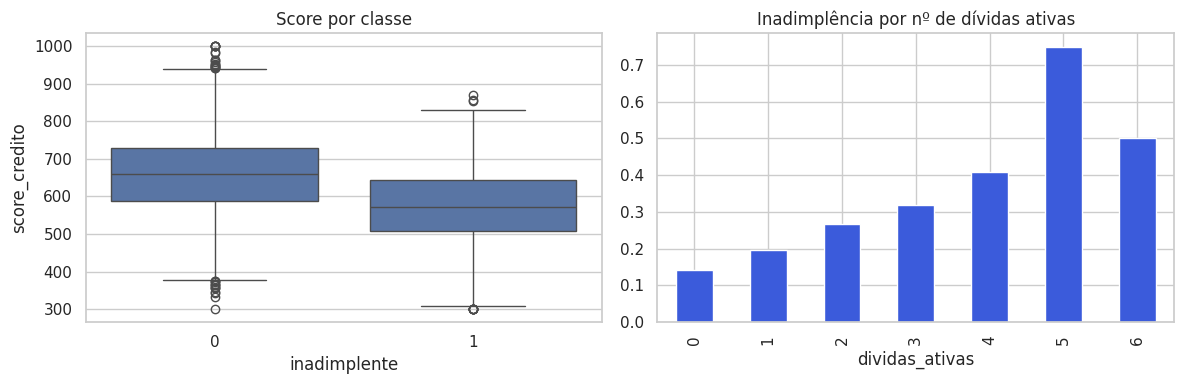

,taxa,contratos
score_credito,,
300-500,0.4782,619
501-600,0.3080,1529
601-700,0.1682,2093
701-800,0.1020,1324
801-1000,0.0184,435


,taxa,contratos
finalidade,,
educacao,0.1893,544
veiculo,0.1924,1507
pessoal,0.2018,2161
reforma,0.2044,856
negocio,0.2768,932


,taxa,contratos
possui_imovel,,
nao,0.225,3555
sim,0.189,2445


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="inadimplente", y="score_credito", ax=ax[0]); ax[0].set_title("Score por classe")
df.groupby("dividas_ativas").inadimplente.mean().plot.bar(ax=ax[1], color="#3b5bdb"); ax[1].set_title("Inadimplência por nº de dívidas ativas")
plt.tight_layout(); plt.show()
display(df.groupby(faixas, observed=True).inadimplente.agg(taxa="mean", contratos="size"))
display(df.groupby("finalidade").inadimplente.agg(taxa="mean", contratos="size").sort_values("taxa"))
display(df.groupby("possui_imovel").inadimplente.agg(taxa="mean", contratos="size"))

**Conclusões da EDA**

- **Proporção:** 1.262 de 6.000 contratos (21,0%) são inadimplentes. As classes são desbalanceadas, então acurácia sozinha engana: responder sempre "paga" já daria 79%.
- **Ausentes:** `renda_mensal` tem 231 (3,9%) e `tempo_emprego_anos` tem 183 (3,1%). Serão imputados com a mediana dentro do Pipeline (sem vazamento).
- **Score:** é o sinal mais forte. A inadimplência cai de ~48% (score até 500) para ~31% (501–600), ~17% (601–700), ~10% (701–800) e ~2% (acima de 800).
- **Finalidade:** "negocio" se destaca com ~28%; as demais ficam entre 19% e 20%.
- **Imóvel:** quem possui imóvel inadimple menos (18,9% contra 22,5%).
- **Dívidas ativas:** o risco cresce com o número de dívidas (14% com zero, 41% com quatro).
- **Coluna descartada:** `id_contrato`. É só um identificador, sem relação causal com o pagamento; usá-lo permitiria ao modelo "decorar" exemplos. Nenhuma outra coluna é vazamento: todas existem no momento do pedido. A `idade` é discutida na Parte 6.

## Parte 2 — Modelagem

In [5]:
problema = PROBLEMAS["credito"]
X_treino, X_teste, y_treino, y_teste = dividir(problema)   # 80/20, estratificado, random_state=42
print(X_treino.shape, X_teste.shape, round(y_treino.mean(), 4), round(y_teste.mean(), 4))
criar_pipeline(problema, LogisticRegression(max_iter=1000))

(4800, 9) (1200, 9) 0.2104 0.21


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

In [6]:
linhas = []
for nome, modelo in candidatos("classificacao").items():
    notas = cross_validate(criar_pipeline(problema, modelo), X_treino, y_treino, cv=5, scoring="roc_auc")["test_score"]
    linhas.append({"algoritmo": nome, "ROC AUC média": notas.mean(), "desvio": notas.std()})
comparacao = pd.DataFrame(linhas).sort_values("ROC AUC média", ascending=False).reset_index(drop=True)
comparacao

,algoritmo,ROC AUC média,desvio
0,Regressão Logística,0.7781,0.0224
1,Random Forest,0.7606,0.0228
2,Gradient Boosting,0.7556,0.0233
3,Árvore de Decisão,0.7106,0.0232


O Pipeline usa `ColumnTransformer`: numéricas → imputação pela mediana + `StandardScaler`; categóricas → imputação pela moda + `OneHotEncoder(handle_unknown="ignore")`. Como tudo é ajustado dentro de cada fold, medianas e médias são aprendidas só com os dados de treino daquele fold.

**Resultado:** a Regressão Logística venceu (ROC AUC ≈ 0,778 ± 0,022), seguida de Random Forest (0,761) e Gradient Boosting (0,756); a árvore simples ficou por último (0,711). Assim como no churn, o risco é gerado por uma soma de efeitos passada por uma sigmoide, ou seja, é aproximadamente linear no logit, e os modelos complexos só acrescentam variância. Bônus: a logística também é o modelo mais explicável, o que é exigido em crédito.

## Parte 3 — Avaliação no teste (usado uma única vez)

Acurácia : 0.8058
Precisão : 0.5888
Recall   : 0.2500
F1       : 0.3510
ROC AUC  : 0.7625


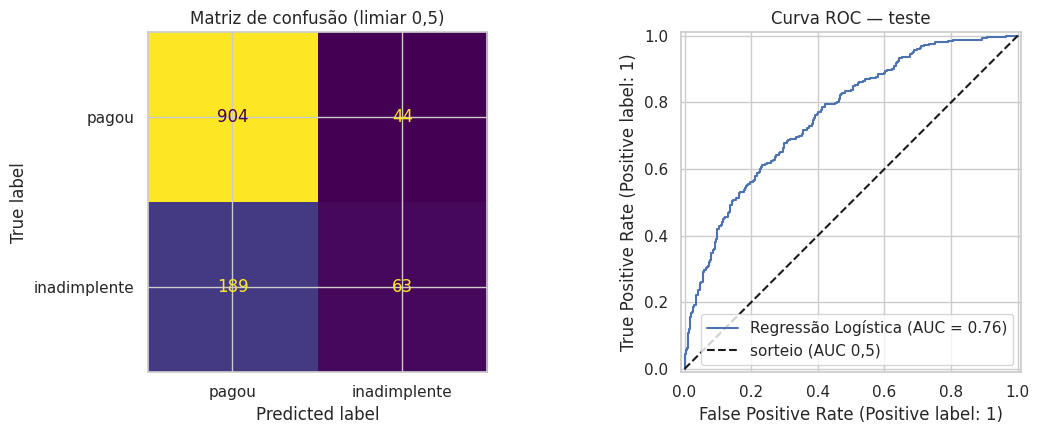

In [7]:
melhor = criar_pipeline(problema, LogisticRegression(max_iter=1000)).fit(X_treino, y_treino)
prob_teste = melhor.predict_proba(X_teste)[:, 1]
prev = (prob_teste >= 0.5).astype(int)
print(f"Acurácia : {accuracy_score(y_teste, prev):.4f}")
print(f"Precisão : {precision_score(y_teste, prev):.4f}")
print(f"Recall   : {recall_score(y_teste, prev):.4f}")
print(f"F1       : {f1_score(y_teste, prev):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_teste, prob_teste):.4f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_teste, prev), display_labels=["pagou", "inadimplente"]).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Matriz de confusão (limiar 0,5)")
RocCurveDisplay.from_predictions(y_teste, prob_teste, ax=ax[1], name="Regressão Logística")
ax[1].plot([0, 1], [0, 1], "k--", label="sorteio (AUC 0,5)"); ax[1].legend(); ax[1].set_title("Curva ROC — teste")
plt.tight_layout(); plt.show()

**Resultados (limiar 0,5):** acurácia 80,6%, precisão 58,9%, recall 25,0%, F1 0,351, ROC AUC 0,762. Matriz: VN = 904, FP = 44, FN = 189, VP = 63.

A acurácia de 80,6% é quase igual à de "aprovar todo mundo" (79%), e o recall de 25% mostra que, no limiar padrão, o modelo deixa passar 3 de cada 4 inadimplentes. A ROC AUC de 0,762 (próxima da validação cruzada, 0,778) indica que o modelo **ordena** bem o risco; o problema está no limiar, tratado na Parte 4.

**Neste negócio** (classe positiva = inadimplente):
- **Falso positivo:** o modelo diz "vai inadimplir" para um bom pagador → o crédito é negado e a fintech perde o lucro do contrato (R$ 1.500), além de um cliente insatisfeito.
- **Falso negativo:** o modelo diz "vai pagar" para quem não paga → o empréstimo é aprovado e vira prejuízo (R$ 8.000).

O **falso negativo é mais caro** (cerca de 5,3 vezes), então devemos privilegiar o recall e baixar o limiar.

## Parte 4 — Limiar de decisão (sem usar o teste)

In [8]:
CUSTO_FN, CUSTO_FP = 8000, 1500   # inadimplente aprovado / bom cliente recusado
prob_cv = cross_val_predict(criar_pipeline(problema, LogisticRegression(max_iter=1000)),
                            X_treino, y_treino, cv=5, method="predict_proba")[:, 1]

def analisar(y, prob, limiar):
    prev = (prob >= limiar).astype(int)
    vn, fp, fn, vp = confusion_matrix(y, prev).ravel()
    return {"limiar": limiar, "precisão": precision_score(y, prev), "recall": recall_score(y, prev),
            "recusados": prev.mean(), "FP": fp, "FN": fn, "custo (R$)": fn * CUSTO_FN + fp * CUSTO_FP}

tabela = pd.DataFrame([analisar(y_treino, prob_cv, t) for t in [0.10, 0.15, 0.19, 0.20, 0.25, 0.30, 0.40, 0.50]])
tabela.style.format({"precisão": "{:.1%}", "recall": "{:.1%}", "recusados": "{:.1%}", "custo (R$)": "R$ {:,.0f}"})

,limiar,precisão,recall,recusados,FP,FN,custo (R$)
0,0.100000,28.7%,91.2%,66.8%,2287,89,"R$ 4,142,500"
1,0.150000,33.3%,82.2%,51.9%,1660,180,"R$ 3,930,000"
2,0.190000,37.8%,75.9%,42.3%,1263,243,"R$ 3,838,500"
3,0.200000,38.8%,74.3%,40.3%,1185,260,"R$ 3,857,500"
4,0.250000,42.8%,63.8%,31.3%,860,366,"R$ 4,218,000"
5,0.300000,47.2%,55.0%,24.5%,620,455,"R$ 4,570,000"
6,0.400000,53.4%,37.9%,14.9%,334,627,"R$ 5,517,000"
7,0.500000,60.9%,24.1%,8.3%,156,767,"R$ 6,370,000"


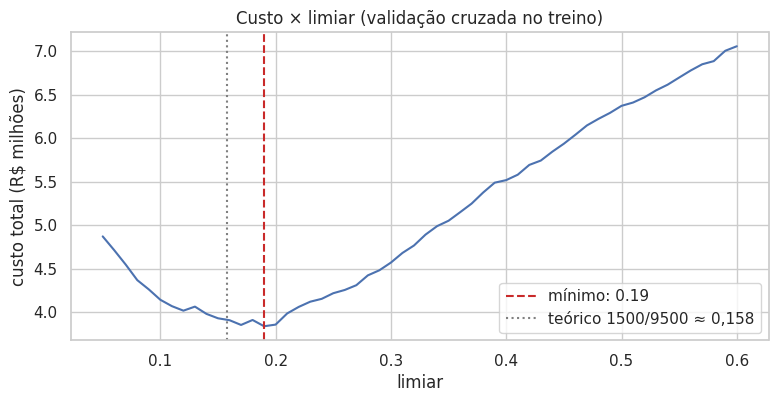

Limiar de menor custo na validação: 0.19


In [9]:
grade = np.round(np.arange(0.05, 0.61, 0.01), 2)
custos = [analisar(y_treino, prob_cv, t)["custo (R$)"] for t in grade]
limiar_otimo = grade[int(np.argmin(custos))]
plt.figure(figsize=(9, 4)); plt.plot(grade, np.array(custos) / 1e6)
plt.axvline(limiar_otimo, color="#c92a2a", ls="--", label=f"mínimo: {limiar_otimo}")
plt.axvline(1500 / 9500, color="gray", ls=":", label="teórico 1500/9500 ≈ 0,158")
plt.xlabel("limiar"); plt.ylabel("custo total (R$ milhões)"); plt.title("Custo × limiar (validação cruzada no treino)")
plt.legend(); plt.show()
print("Limiar de menor custo na validação:", limiar_otimo)

In [10]:
comparar = pd.DataFrame([analisar(y_teste, prob_teste, t) for t in [limiar_otimo, 0.5]])
comparar.loc[len(comparar)] = {"limiar": "aprovar todos", "FP": 0, "FN": int(y_teste.sum()),
                               "custo (R$)": int(y_teste.sum()) * CUSTO_FN, "recusados": 0.0}
comparar

,limiar,precisão,recall,recusados,FP,FN,custo (R$)
0,0.19,0.3487,0.7183,0.4325,338,71,1075000
1,0.5,0.5888,0.2500,0.0892,44,189,1578000
2,aprovar todos,NaN,NaN,0.0000,0,252,2016000


**Recomendação: limiar 0,19.** Ele minimiza o custo na validação cruzada do treino (R$ 3,84 milhões nos 4.800 contratos, contra R$ 6,37 milhões no limiar 0,5). A curva é bem plana entre 0,15 e 0,20, o que dá segurança à escolha; e bate com a teoria: recusar vale a pena quando p·8000 > (1−p)·1500, isto é, p > 1500/9500 ≈ 0,16.

**Custo no conjunto de teste (1.200 contratos) com limiar 0,19: R$ 1.075.000** (338 FP × R$ 1.500 + 71 FN × R$ 8.000), com recall de 71,8% e precisão de 34,9%. Para comparar: o limiar 0,5 custaria R$ 1.578.000 e aprovar todo mundo, R$ 2.016.000. A economia é de cerca de R$ 500 mil em relação ao limiar padrão.

Ressalva de negócio: o limiar 0,19 marca ~43% dos pedidos como risco alto. Na prática, esses casos deveriam ir para análise humana (ou receber condições diferentes, como valor menor ou garantia), e não ser recusados automaticamente.

## Parte 5 — Integração ao sistema

Alterações feitas (arquivos incluídos na entrega):

1. **`config.py`**: novo problema `credito` em `PROBLEMAS`, com as 9 features, limites, opções e `"limiar": 0.19`.
2. **`app.py`**: nenhuma mudança necessária. Como tudo é lido do `config.py`, a nova aba, a validação e a rota `/api/prever/credito` funcionam automaticamente.
3. **`templates/index.html`**: a cor e a mensagem da previsão passam a usar o limiar do problema (`p.limiar ?? 0.5`), mostrando "Risco alto: encaminhar para análise humana" ou "Risco baixo". Também aceita `?aba=credito` na URL.

Após `python treinar.py`, o terminal mostra o terceiro bloco `=== Risco de crédito ===` com a mesma comparação da Parte 2. As capturas estão em `prints/`: perfil de risco alto (96,6%) e de risco baixo (0,6%).

In [11]:
import json, joblib
from config import MODELOS
modelo_app = joblib.load(MODELOS / "credito.joblib")
casos = pd.DataFrame([
    {"idade": 24, "renda_mensal": 2200, "tempo_emprego_anos": 0.5, "score_credito": 420, "dividas_ativas": 4,
     "possui_imovel": "nao", "finalidade": "negocio", "prazo_meses": 12, "valor_emprestimo": 12000},
    {"idade": 45, "renda_mensal": 12000, "tempo_emprego_anos": 12, "score_credito": 820, "dividas_ativas": 0,
     "possui_imovel": "sim", "finalidade": "reforma", "prazo_meses": 48, "valor_emprestimo": 20000}],
    index=["risco alto", "risco baixo"])
casos.assign(probabilidade=modelo_app.predict_proba(casos)[:, 1].round(4))

,idade,renda_mensal,tempo_emprego_anos,score_credito,dividas_ativas,possui_imovel,finalidade,prazo_meses,valor_emprestimo,probabilidade
risco alto,24,2200,0.5,420,4,nao,negocio,12,12000,0.9656
risco baixo,45,12000,12.0,820,0,sim,reforma,48,20000,0.0064


## Parte 6 — Reflexão ética

Modelos de crédito aprendem com decisões e resultados do passado, então podem reproduzir e escalar discriminações históricas: se um grupo teve menos acesso a crédito ou recebeu condições piores, isso aparece nos dados como "mais risco", e o modelo transforma desigualdade em regra automática. Eu **não usaria** gênero, raça/cor, religião, orientação sexual, estado civil, origem ou deficiência, nem substitutos óbvios delas, como CEP ou bairro (que refletem renda e etnia), nome ou foto, mesmo que melhorassem a ROC AUC. Também retiraria a **idade** da versão em produção: neste conjunto, ela custa pouco (a ROC AUC na validação cruzada cai só de 0,778 para 0,772) e penalizar idade pode ser discriminatório e conflitar com o Estatuto da Pessoa Idosa; se fosse mantida, exigiria justificativa e auditoria. Além de retirar features, é preciso medir precisão, recall e taxa de recusa **por grupo**, porque proxies podem trazer o viés de volta. Na LGPD, o caso envolve dados pessoais (e, se usados, dados sensíveis, art. 11), e se aplicam os princípios de finalidade, necessidade e não discriminação (art. 6º): coletar só o necessário para avaliar crédito e nunca para fins discriminatórios ilícitos. O art. 20 garante ao titular o direito de pedir revisão de decisões tomadas unicamente por tratamento automatizado e de receber informações claras sobre os critérios usados, o que reforça a escolha de um modelo interpretável (regressão logística) e o desenho com humano no circuito para os casos de risco alto.

In [12]:
sem_idade = {**problema, "features": {k: v for k, v in problema["features"].items() if k != "idade"}}
for nome, p in [("com idade", problema), ("sem idade", sem_idade)]:
    n = cross_validate(criar_pipeline(p, LogisticRegression(max_iter=1000)), X_treino, y_treino, cv=5, scoring="roc_auc")["test_score"]
    print(f"{nome}: ROC AUC {n.mean():.4f} ± {n.std():.4f}")

com idade: ROC AUC 0.7781 ± 0.0224
sem idade: ROC AUC 0.7723 ± 0.0259


## Desafios extras (bônus)

### 1. Feature "comprometimento de renda" = (valor_emprestimo / prazo_meses) / renda_mensal

In [13]:
def com_comprometimento(X):
    X = X.copy()
    X["comprometimento"] = X["valor_emprestimo"] / X["prazo_meses"] / X["renda_mensal"]   # NaN se renda ausente -> imputado no Pipeline
    return X
problema_c = {**problema, "features": {**problema["features"], "comprometimento": {"tipo": "numero"}}}
res = []
for nome, modelo in candidatos("classificacao").items():
    a = cross_validate(criar_pipeline(problema, modelo), X_treino, y_treino, cv=5, scoring="roc_auc")["test_score"].mean()
    b = cross_validate(criar_pipeline(problema_c, modelo), com_comprometimento(X_treino), y_treino, cv=5, scoring="roc_auc")["test_score"].mean()
    res.append({"algoritmo": nome, "sem": a, "com comprometimento": b, "diferença": b - a})
pd.DataFrame(res)

,algoritmo,sem,com comprometimento,diferença
0,Regressão Logística,0.7781,0.7779,-1.5152e-04
1,Árvore de Decisão,0.7106,0.7138,3.2400e-03
2,Random Forest,0.7606,0.7605,-4.4411e-05
3,Gradient Boosting,0.7556,0.7571,1.5230e-03


A feature é calculada linha a linha (não usa estatísticas do conjunto), então não causa vazamento. O efeito na ROC AUC foi **praticamente nulo** (variações de ±0,003, bem dentro do desvio de ±0,02 entre folds). Faz sentido: o comprometimento tem efeito real nos dados, mas modesto perto de score e dívidas ativas, e o modelo já recebe valor, prazo e renda separadamente. Lição: nem toda feature "de negócio" aumenta o desempenho, e por isso medimos em vez de supor.

### 2. Ajuste de hiperparâmetros com GridSearchCV

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier
buscas = {
  "Regressão Logística": (LogisticRegression(max_iter=1000), {"modelo__C": [0.01, 0.1, 1, 10]}),
  "Gradient Boosting": (HistGradientBoostingClassifier(random_state=SEMENTE),
        {"modelo__learning_rate": [0.03, 0.1], "modelo__max_depth": [2, 3, None], "modelo__max_iter": [100, 300]}),
}
for nome, (modelo, grade_hp) in buscas.items():
    g = GridSearchCV(criar_pipeline(problema, modelo), grade_hp, cv=5, scoring="roc_auc").fit(X_treino, y_treino)
    print(f"{nome}: {g.best_params_} -> ROC AUC {g.best_score_:.4f}")

Regressão Logística: {'modelo__C': 0.1} -> ROC AUC 0.7782


Gradient Boosting: {'modelo__learning_rate': 0.1, 'modelo__max_depth': 2, 'modelo__max_iter': 100} -> ROC AUC 0.7708


A logística quase não muda (melhor C = 0,1 → 0,778, igual ao padrão). O Gradient Boosting melhora com árvores rasas (max_depth = 2, learning_rate = 0,1, 100 iterações): de 0,756 para 0,771, mas ainda abaixo da logística. Isso reforça a conclusão da Parte 2: a relação é quase linear, e o modelo simples e explicável é a escolha certa.

### 3. `class_weight="balanced"`

In [15]:
linhas = []
for cw in [None, "balanced"]:
    r = cross_validate(criar_pipeline(problema, LogisticRegression(max_iter=1000, class_weight=cw)), X_treino, y_treino,
                       cv=5, scoring=["roc_auc", "precision", "recall", "f1"])
    linhas.append({"class_weight": str(cw), **{k[5:]: v.mean() for k, v in r.items() if k.startswith("test_")}})
pd.DataFrame(linhas)

,class_weight,roc_auc,precision,recall,f1
0,None,0.7781,0.6113,0.2406,0.3446
1,balanced,0.7778,0.3909,0.7109,0.5042


Com `balanced`, os erros na classe minoritária pesam mais no treino: o recall (limiar 0,5) sobe de ~24% para ~71% e a precisão cai de ~61% para ~39%, enquanto a ROC AUC fica igual (0,778). Ou seja, o modelo não ficou "melhor" em ordenar o risco; o efeito é parecido com baixar o limiar. Por isso, ajustar o limiar pelo custo (Parte 4) é a forma mais direta e transparente de chegar ao mesmo resultado.